In [ ]:
import os
import time
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import drive
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# El nombre de la carpeta
dataset_path = '/content/drive/MyDrive/RootKit/PlantVillage'

# Verificar que lo encuentra
if os.path.exists(dataset_path):
    print("Dataset encontrado")
else:
    print("No encontrado")

Dataset encontrado


Total de clases: 15

  Pepper__bell___Bacterial_spot: 997 imágenes
Nombre de la imagen : Pepper__bell___Bacterial_spot
Tamanio               : 0.02 MB  18,403 bytes
Ancho               : 256 pixeles
Alto                : 256 pixeles
Dimensiones         : 256x256


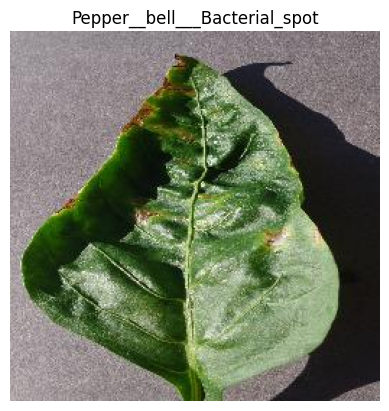

  Pepper__bell___healthy: 1478 imágenes
Nombre de la imagen : Pepper__bell___healthy
Tamanio               : 0.02 MB  16,016 bytes
Ancho               : 256 pixeles
Alto                : 256 pixeles
Dimensiones         : 256x256


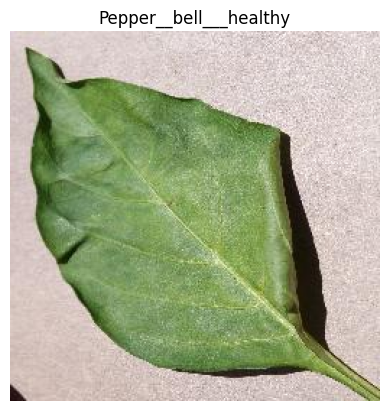

  Potato___Early_blight: 1000 imágenes
Nombre de la imagen : Potato___Early_blight
Tamanio               : 0.02 MB  23,182 bytes
Ancho               : 256 pixeles
Alto                : 256 pixeles
Dimensiones         : 256x256


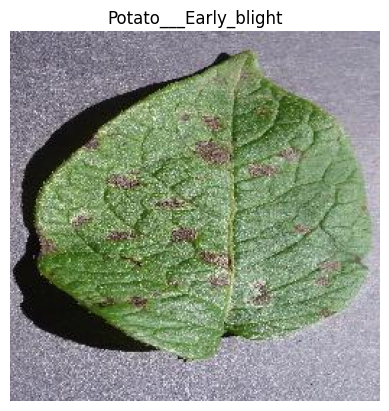

  Potato___Late_blight: 1000 imágenes
Nombre de la imagen : Potato___Late_blight
Tamanio               : 0.02 MB  16,013 bytes
Ancho               : 256 pixeles
Alto                : 256 pixeles
Dimensiones         : 256x256


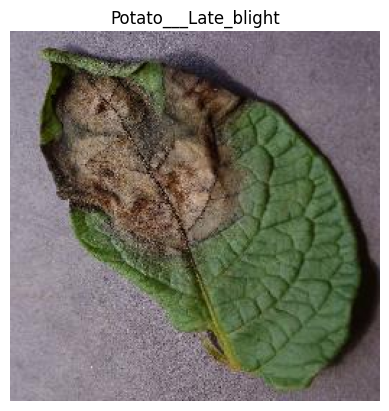

  Potato___healthy: 152 imágenes
Nombre de la imagen : Potato___healthy
Tamanio               : 0.02 MB  20,458 bytes
Ancho               : 256 pixeles
Alto                : 256 pixeles
Dimensiones         : 256x256


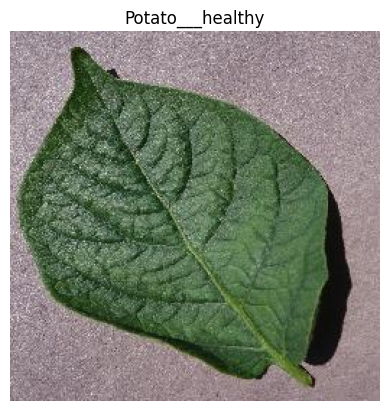

  Tomato_Bacterial_spot: 2127 imágenes
Nombre de la imagen : Tomato_Bacterial_spot
Tamanio               : 0.01 MB  13,426 bytes
Ancho               : 256 pixeles
Alto                : 256 pixeles
Dimensiones         : 256x256


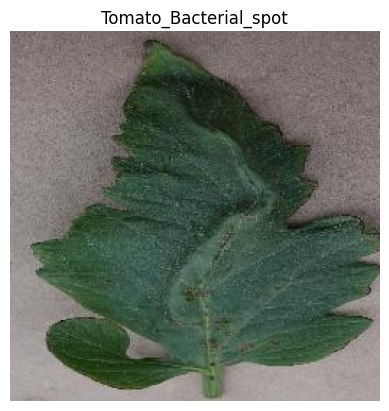

  Tomato_Early_blight: 1000 imágenes
Nombre de la imagen : Tomato_Early_blight
Tamanio               : 0.01 MB  11,592 bytes
Ancho               : 256 pixeles
Alto                : 256 pixeles
Dimensiones         : 256x256


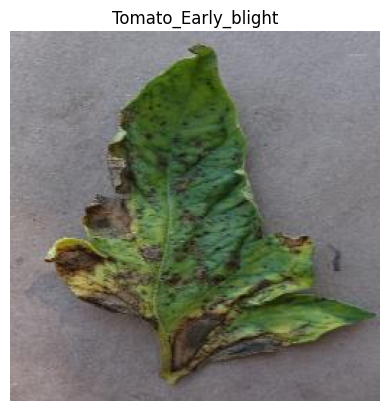

  Tomato_Late_blight: 1909 imágenes
Nombre de la imagen : Tomato_Late_blight
Tamanio               : 0.01 MB  10,068 bytes
Ancho               : 256 pixeles
Alto                : 256 pixeles
Dimensiones         : 256x256


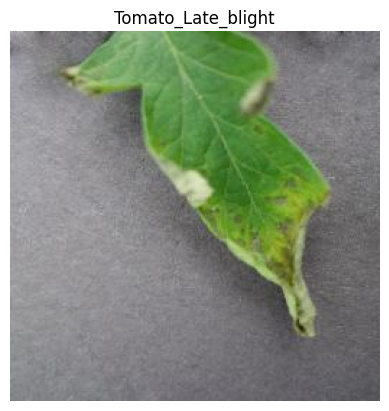

  Tomato_Leaf_Mold: 952 imágenes
Nombre de la imagen : Tomato_Leaf_Mold
Tamanio               : 0.02 MB  17,900 bytes
Ancho               : 256 pixeles
Alto                : 256 pixeles
Dimensiones         : 256x256


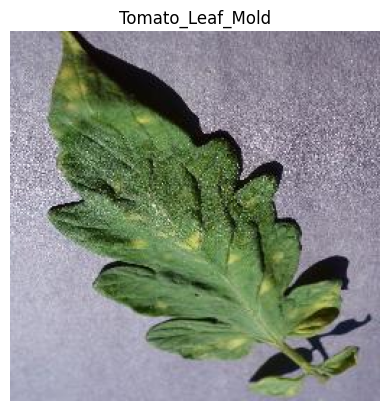

  Tomato_Septoria_leaf_spot: 1771 imágenes
Nombre de la imagen : Tomato_Septoria_leaf_spot
Tamanio               : 0.02 MB  18,388 bytes
Ancho               : 256 pixeles
Alto                : 256 pixeles
Dimensiones         : 256x256


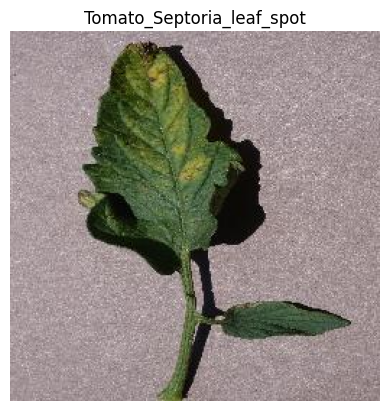

  Tomato_Spider_mites_Two_spotted_spider_mite: 1676 imágenes
Nombre de la imagen : Tomato_Spider_mites_Two_spotted_spider_mite
Tamanio               : 0.02 MB  22,768 bytes
Ancho               : 256 pixeles
Alto                : 256 pixeles
Dimensiones         : 256x256


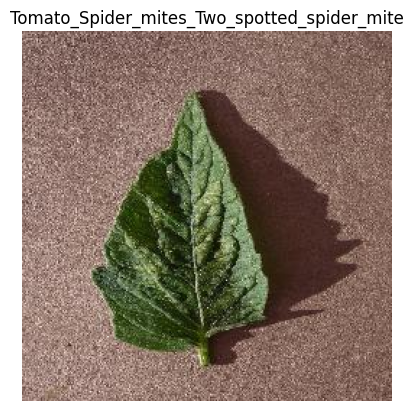

  Tomato__Target_Spot: 1404 imágenes
Nombre de la imagen : Tomato__Target_Spot
Tamanio               : 0.02 MB  20,705 bytes
Ancho               : 256 pixeles
Alto                : 256 pixeles
Dimensiones         : 256x256


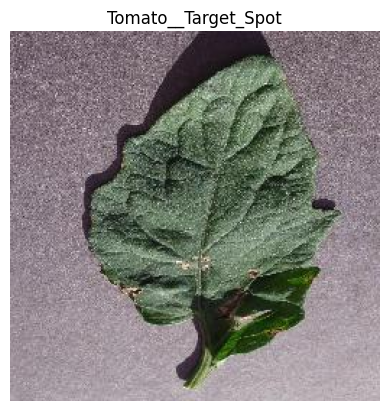

  Tomato__Tomato_YellowLeaf__Curl_Virus: 3209 imágenes
Nombre de la imagen : Tomato__Tomato_YellowLeaf__Curl_Virus
Tamanio               : 0.01 MB  12,782 bytes
Ancho               : 256 pixeles
Alto                : 256 pixeles
Dimensiones         : 256x256


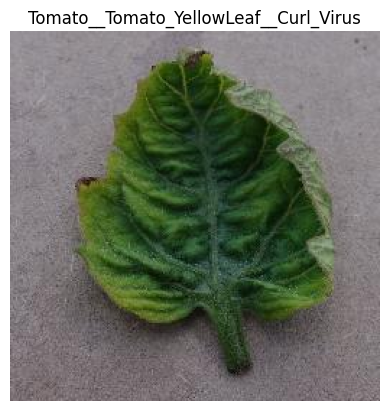

  Tomato__Tomato_mosaic_virus: 373 imágenes
Nombre de la imagen : Tomato__Tomato_mosaic_virus
Tamanio               : 0.01 MB  15,676 bytes
Ancho               : 256 pixeles
Alto                : 256 pixeles
Dimensiones         : 256x256


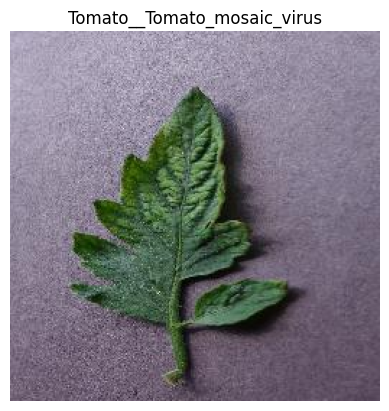

  Tomato_healthy: 1591 imágenes
Nombre de la imagen : Tomato_healthy
Tamanio               : 0.01 MB  12,092 bytes
Ancho               : 256 pixeles
Alto                : 256 pixeles
Dimensiones         : 256x256


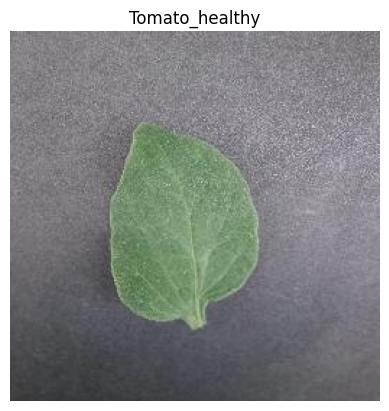


Total de imagenes: 20639 imagenes


In [ ]:
clases = [f for f in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, f))]
print(f"Total de clases: {len(clases)}\n")

nt = 0

for clase in sorted(clases):
    n = len(os.listdir(os.path.join(dataset_path, clase)))
    print(f"  {clase}: {n} imágenes")
    nt = n + nt

    imagenes = os.listdir(os.path.join(dataset_path, clase))
    ruta_imagen = os.path.join(dataset_path, clase, imagenes[0])

    nombre = os.path.basename(ruta_imagen)
    print("Nombre de la imagen :", clase)

    # Tamaño
    size_bytes = os.path.getsize(ruta_imagen)
    size_mb = size_bytes / (1024 * 1024)
    print(f"Tamanio               : {round(size_mb, 2)} MB  {size_bytes:,} bytes")
    img = Image.open(ruta_imagen)

    # Dimensiones
    ancho, alto = img.size
    print("Ancho               :", ancho, "pixeles")
    print("Alto                :", alto, "pixeles")
    print("Dimensiones         :", f"{ancho}x{alto}")
    # 2. La abre

    # 3. La muestras
    plt.imshow(img)
    plt.title(clase)
    plt.axis('off')
    plt.show()

print(f"\nTotal de imagenes: {nt} imagenes")

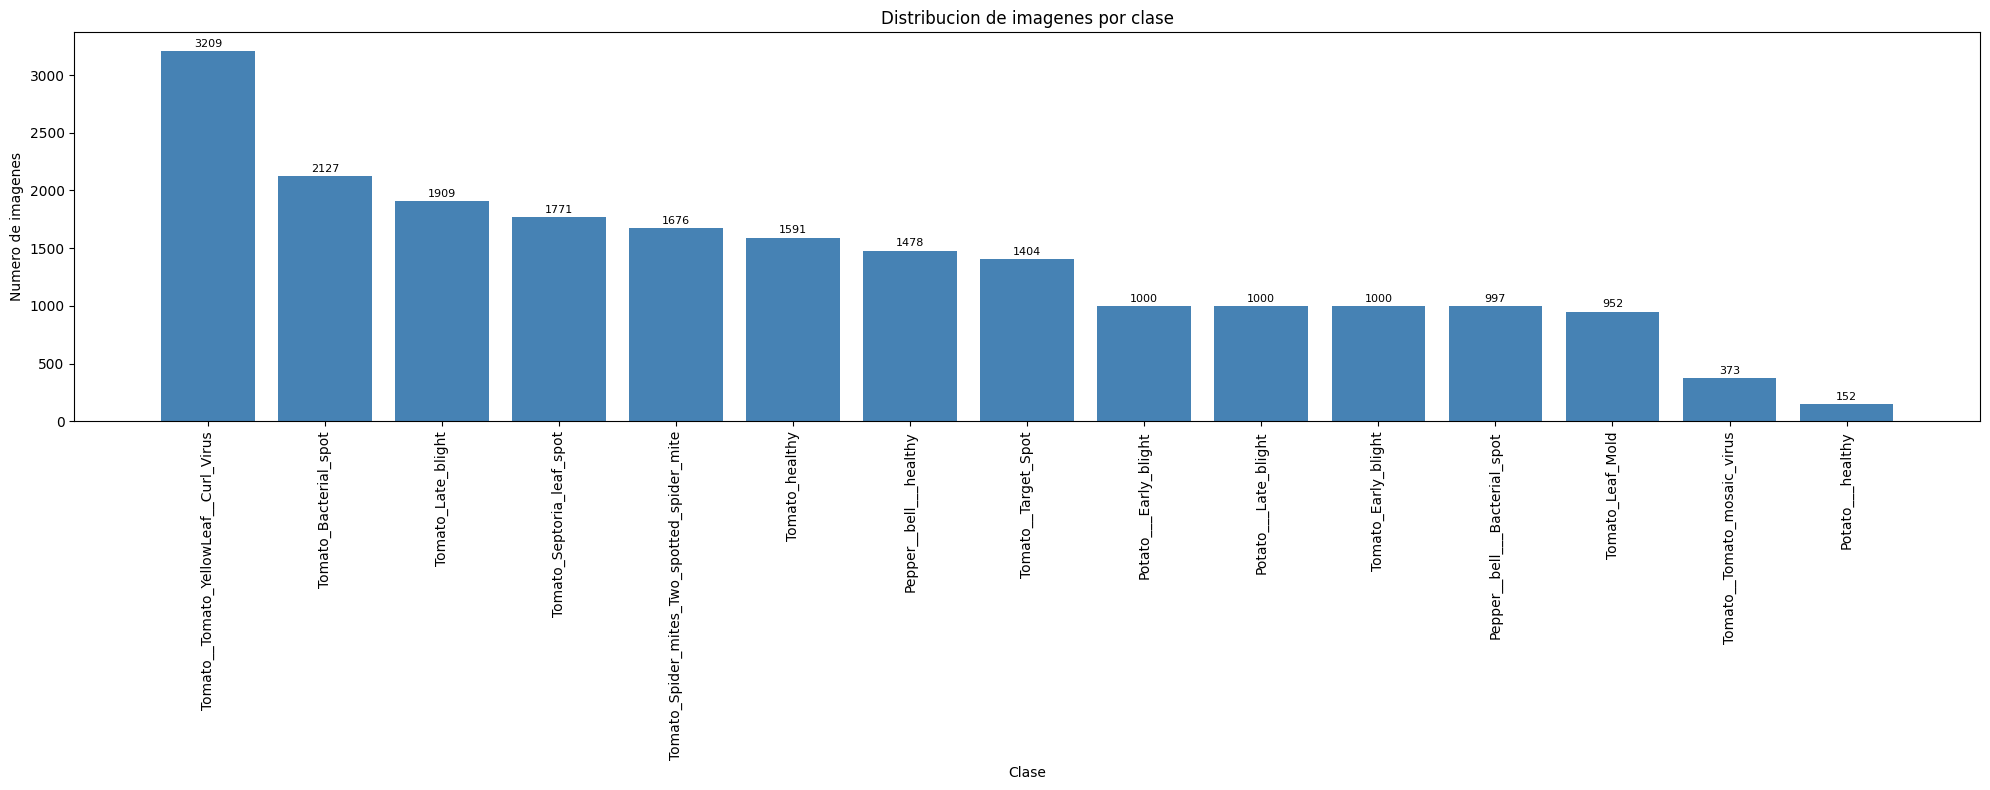

In [ ]:
# Contar imagenes por clase
conteo = {}
for clase in sorted(clases):
    n = len(os.listdir(os.path.join(dataset_path, clase)))
    conteo[clase] = n

# Ordenar de mayor a menor
conteo_ordenado = dict(sorted(conteo.items(), key=lambda x: x[1], reverse=True))

# Datos para la grafica
nombres = list(conteo_ordenado.keys())
valores = list(conteo_ordenado.values())

# Grafica
plt.figure(figsize=(20, 8))
barras = plt.bar(nombres, valores, color='steelblue')

# Numero encima de cada barra
for barra, valor in zip(barras, valores):
    plt.text(barra.get_x() + barra.get_width()/2,
             barra.get_height() + 20,
             str(valor),
             ha='center', va='bottom', fontsize=8)

plt.xticks(rotation=90)
plt.xlabel('Clase')
plt.ylabel('Numero de imagenes')
plt.title('Distribucion de imagenes por clase')
plt.tight_layout()
plt.show()

In [ ]:
# Recopilar todas las rutas e etiquetas
rutas = []
etiquetas = []

for clase in sorted(clases):
    carpeta = os.path.join(dataset_path, clase)
    for imagen in os.listdir(carpeta):
        rutas.append(os.path.join(carpeta, imagen))
        etiquetas.append(clase)

print(f"Total de imágenes: {len(rutas)}")

Total de imágenes: 20639


In [ ]:

# Primero separas el 70% train del 30% restante
rutas_train, rutas_temp, etiquetas_train, etiquetas_temp = train_test_split(
    rutas, etiquetas,
    test_size=0.30,     # 30% para val + test
    random_state=42,    # para que el split sea siempre igual
    stratify=etiquetas  # que cada clase quede proporcionalmente en cada grupo
)

# Luego divides ese 30% en val (15%) y test (15%)
rutas_val, rutas_test, etiquetas_val, etiquetas_test = train_test_split(
    rutas_temp, etiquetas_temp,
    test_size=0.50,     # 50% del 30% = 15% del total
    random_state=42,
    stratify=etiquetas_temp
)

print(f"Train: {len(rutas_train)} imagenes")  # 70%
print(f"Val:   {len(rutas_val)} imagenes")    # 15%
print(f"Test:  {len(rutas_test)} imagenes")   # 15%

Train: 14447 imagenes
Val:   3096 imagenes
Test:  3096 imagenes


In [ ]:

# Transformaciones para train
train_datagen = ImageDataGenerator(rescale=1./255)

# Transformaciones para val y test (solo normalización, sin nada extra)
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Generador TRAIN
train_gen = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),   # resize al vuelo
    batch_size=32,
    classes=sorted(clases),
    subset=None
)

Found 20638 images belonging to 15 classes.


In [ ]:
## Data Augmentation ##
import pandas as pd
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

# ── Convertir las listas de Carlos a DataFrames ──────────────────
# (para poder usarlas con flow_from_dataframe)
df_train = pd.DataFrame({'ruta': rutas_train, 'etiqueta': etiquetas_train})
df_val   = pd.DataFrame({'ruta': rutas_val,   'etiqueta': etiquetas_val})
df_test  = pd.DataFrame({'ruta': rutas_test,  'etiqueta': etiquetas_test})

print(f"Train: {len(df_train)} imágenes")
print(f"Val:   {len(df_val)} imágenes")
print(f"Test:  {len(df_test)} imágenes")

# ── Generadores ──────────────────────────────────────────────────
# Train: CON augmentation
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Val y Test: SOLO normalización, sin augmentation
val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# ── Flows usando el split 70/15/15 de Carlos ─────────────────────
train_gen = train_datagen.flow_from_dataframe(
    dataframe=df_train,
    x_col='ruta',
    y_col='etiqueta',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

val_gen = val_test_datagen.flow_from_dataframe(
    dataframe=df_val,
    x_col='ruta',
    y_col='etiqueta',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

test_gen = val_test_datagen.flow_from_dataframe(
    dataframe=df_test,
    x_col='ruta',
    y_col='etiqueta',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

print("\nGeneradores listos:")
print(f"  train_gen : {train_gen.samples} imágenes")
print(f"  val_gen   : {val_gen.samples} imágenes")
print(f"  test_gen  : {test_gen.samples} imágenes")

# ── Backbone MobileNetV2 para extracción de features ─────────────
base_model = MobileNetV2(weights='imagenet', include_top=False, pooling='avg', input_shape=(224, 224, 3))

def extract_features_batch(gen):
    print("Extrayendo features por lotes...")
    features = base_model.predict(gen, verbose=1)
    return features

Train: 14447 imágenes
Val:   3096 imágenes
Test:  3096 imágenes
Found 14446 validated image filenames belonging to 15 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:920: UserWarning: Found 1 invalid image filename(s) in x_col="ruta". These filename(s) will be ignored.
  warnings.warn(


Found 3096 validated image filenames belonging to 15 classes.
Found 3096 validated image filenames belonging to 15 classes.

Generadores listos:
  train_gen : 14446 imágenes
  val_gen   : 3096 imágenes
  test_gen  : 3096 imágenes


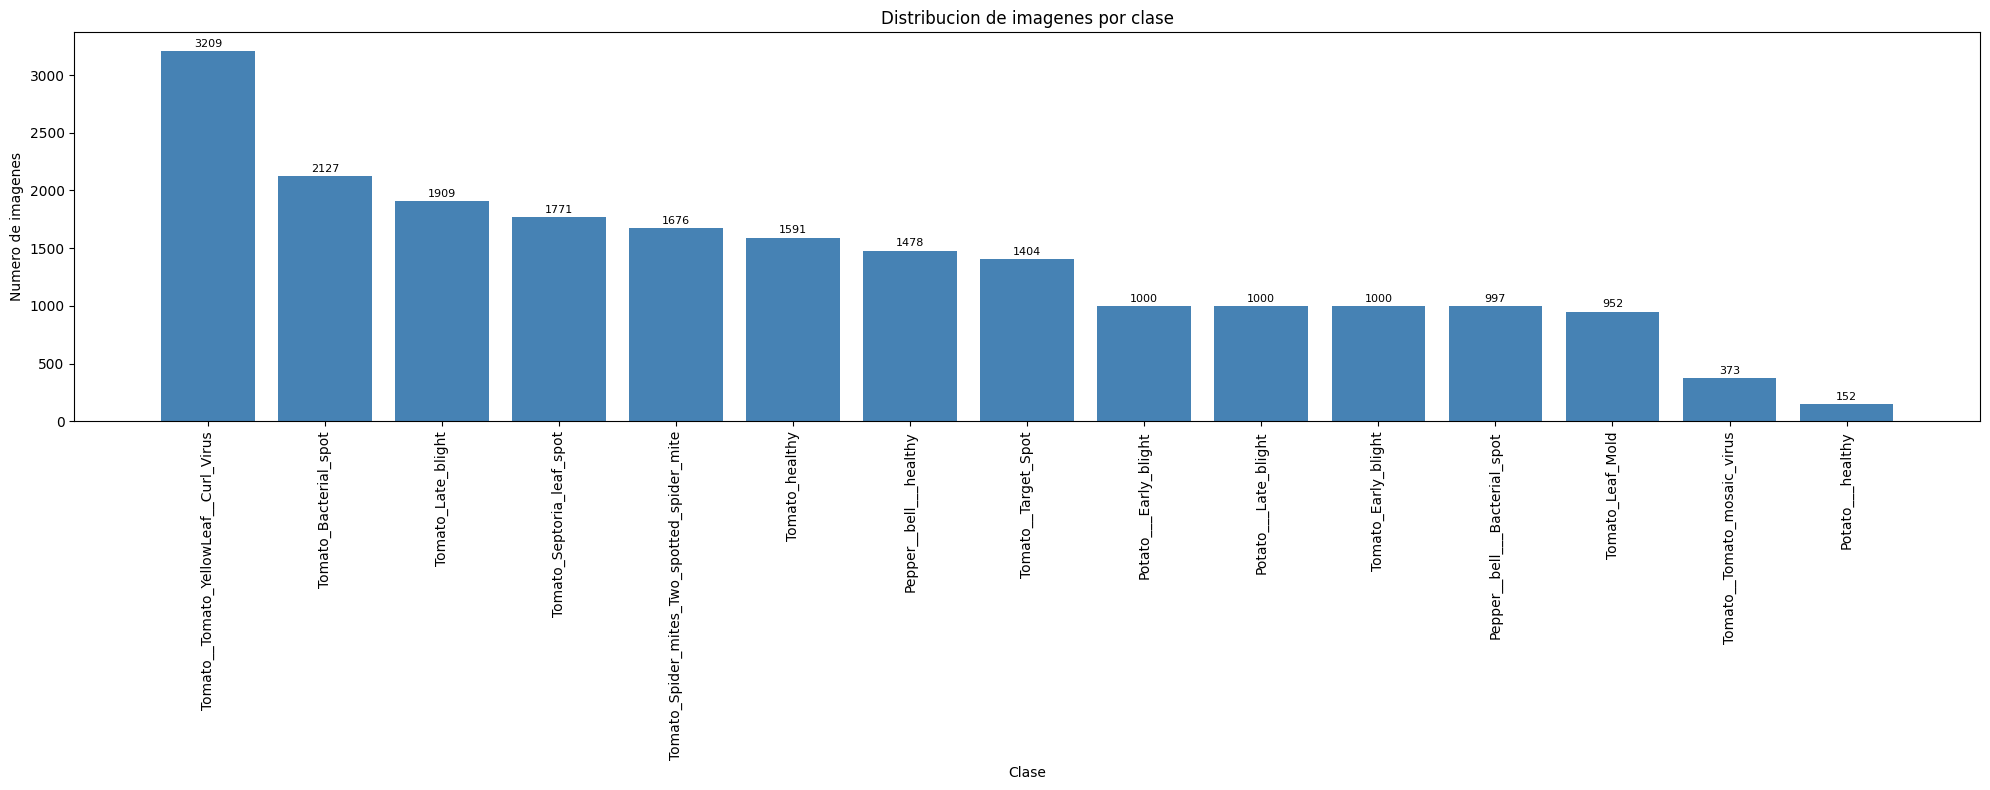

Gráfica guardada


In [ ]:
import os

GRAFICAS_PATH = '/content/drive/MyDrive/RootKit/reports/figures/'
os.makedirs(GRAFICAS_PATH, exist_ok=True)

# Volver a generar y guardar la gráfica de distribución
plt.figure(figsize=(20, 8))
barras = plt.bar(nombres, valores, color='steelblue')

for barra, valor in zip(barras, valores):
    plt.text(barra.get_x() + barra.get_width()/2,
             barra.get_height() + 20,
             str(valor),
             ha='center', va='bottom', fontsize=8)

plt.xticks(rotation=90)
plt.xlabel('Clase')
plt.ylabel('Numero de imagenes')
plt.title('Distribucion de imagenes por clase')
plt.tight_layout()
plt.savefig(GRAFICAS_PATH + 'distribucion_clases.png', dpi=150)
plt.show()

print("Gráfica guardada")

In [ ]:
## Etiquetas de Severidad para Regresión ##

# Mapa de severidad por clase (0.0 = sana, 1.0 = muy grave)
mapa_severidad = {
    # Pepper
    'Pepper__bell___Bacterial_spot' : 0.7,
    'Pepper__bell___healthy'        : 0.0,

    # Potato
    'Potato___Early_blight'         : 0.6,
    'Potato___Late_blight'          : 0.9,
    'Potato___healthy'              : 0.0,

    # Tomato
    'Tomato_Bacterial_spot'         : 0.7,
    'Tomato_Early_blight'           : 0.6,
    'Tomato_Late_blight'            : 0.9,
    'Tomato_Leaf_Mold'              : 0.5,
    'Tomato_Septoria_leaf_spot'     : 0.6,
    'Tomato_Spider_mites_Two_spotted_spider_mite' : 0.5,
    'Tomato__Target_Spot'           : 0.6,
    'Tomato__Tomato_YellowLeaf__Curl_Virus'       : 0.8,
    'Tomato__Tomato_mosaic_virus'   : 0.7,
    'Tomato_healthy'                : 0.0,
}

# Convertir etiquetas de clase a valores de severidad
severidad_train = [mapa_severidad[e] for e in etiquetas_train]
severidad_val   = [mapa_severidad[e] for e in etiquetas_val]
severidad_test  = [mapa_severidad[e] for e in etiquetas_test]

# Verificar
print("Ejemplos de severidad asignada:")
for i in range(5):
    print(f"  {etiquetas_train[i]:45s} → {severidad_train[i]}")

print(f"\nTotal severidades generadas:")
print(f"  Train : {len(severidad_train)}")
print(f"  Val   : {len(severidad_val)}")
print(f"  Test  : {len(severidad_test)}")

Ejemplos de severidad asignada:
  Potato___Late_blight                          → 0.9
  Pepper__bell___healthy                        → 0.0
  Tomato__Tomato_mosaic_virus                   → 0.7
  Tomato_Leaf_Mold                              → 0.5
  Potato___Late_blight                          → 0.9

Total severidades generadas:
  Train : 14447
  Val   : 3096
  Test  : 3096


In [ ]:
import numpy as np
import os

SAVE_PATH = '/content/drive/MyDrive/RootKit/procesado/'
os.makedirs(SAVE_PATH, exist_ok=True)

# Splits de Carlos
np.save(SAVE_PATH + 'rutas_train.npy',     rutas_train)
np.save(SAVE_PATH + 'rutas_val.npy',       rutas_val)
np.save(SAVE_PATH + 'rutas_test.npy',      rutas_test)
np.save(SAVE_PATH + 'etiquetas_train.npy', etiquetas_train)
np.save(SAVE_PATH + 'etiquetas_val.npy',   etiquetas_val)
np.save(SAVE_PATH + 'etiquetas_test.npy',  etiquetas_test)

# Severidades de Othon
np.save(SAVE_PATH + 'severidad_train.npy', severidad_train)
np.save(SAVE_PATH + 'severidad_val.npy',   severidad_val)
np.save(SAVE_PATH + 'severidad_test.npy',  severidad_test)

print("Splits de Carlos guardados")
print("Severidades de Othon guardadas")

Splits de Carlos guardados
Severidades de Othon guardadas
